## 1-Setup

In [1]:
# Local project setup
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()

print("Project root:", PROJECT_ROOT)
print("Contents:", os.listdir(PROJECT_ROOT))

Project root: /Volumes/T7/Deep Learning Project/deep-learning-video-inpainting-project-1
Contents: ['.git', 'data', 'ECE685_Video_inpainting.ipynb', 'models', 'README.md', 'outputs', 'ECE_VideoInpainting_HuggingFace.ipynb', 'figures', 'scripts', '.gitignore', '._ECE_VideoInpainting_HuggingFace.ipynb']


In [ ]:
# Uncomment when running for the first time to install dependencies
# %pip install -q diffusers==0.24.0 huggingface_hub==0.25.0 transformers==4.38.0 accelerate==0.27.0 peft==0.9.0

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Clone AnimateDiff only if it is not already present
import os

if not os.path.exists("animatediff"):
    !git clone https://github.com/guoyww/AnimateDiff.git animatediff
else:
    print("animatediff folder already exists")

Cloning into 'animatediff'...
remote: Enumerating objects: 718, done.
remote: Counting objects: 100% (287/287), done.
remote: Compressing objects: 100% (93/93), done.
remote: Total 718 (delta 213), reused 194 (delta 194), pack-reused 431 (from 1)
Receiving objects: 100% (718/718), 60.36 MiB | 16.05 MiB/s, done.
Resolving deltas: 100% (297/297), done.


In [ ]:
import sys

sys.path.append("animatediff")

print("Added animatediff to path")

Added animatediff to path


In [ ]:
import os

print(os.listdir("animatediff"))

['.git', '._.git', '.gitignore', '._.gitignore', 'LICENSE.txt', '._LICENSE.txt', 'README.md', '._README.md', '__assets__', '.___assets__', 'animatediff', '._animatediff', 'app.py', '._app.py', 'configs', '._configs', 'models', '._models', 'requirements.txt', '._requirements.txt', 'scripts', '._scripts', 'train.py', '._train.py']


In [ ]:
# import os

# os.makedirs("data/raw", exist_ok=True)
# os.makedirs("data/processed", exist_ok=True)
# os.makedirs("models/base_sd", exist_ok=True)
# os.makedirs("models/motion_module", exist_ok=True)
# os.makedirs("outputs", exist_ok=True)

# print("Folders ready")

Folders ready


In [ ]:
from huggingface_hub import login
import os
from getpass import getpass

HF_TOKEN = os.getenv("HF_TOKEN")
if HF_TOKEN is None:
    HF_TOKEN = getpass("Enter your Hugging Face token: ")

login(token=HF_TOKEN)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /Users/arushisingh/.cache/huggingface/token
Login successful


In [7]:
from huggingface_hub import snapshot_download
import os

os.makedirs("models/base_sd", exist_ok=True)

snapshot_download(
    repo_id="runwayml/stable-diffusion-v1-5",
    local_dir="models/base_sd",
    local_dir_use_symlinks=False,
)

print("Base SD model downloaded to models/base_sd")

/Users/arushisingh/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1204: UserWarning: `local_dir_use_symlinks` parameter is deprecated and will be ignored. The process to download files to a local folder has been updated and do not rely on symlinks anymore. You only need to pass a destination folder as`local_dir`.
For more details, check out https://huggingface.co/docs/huggingface_hub/main/en/guides/download#download-files-to-local-folder.
  warnings.warn(


Fetching 36 files:   0%|          | 0/36 [00:00<?, ?it/s]

.gitattributes: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

preprocessor_config.json:   0%|          | 0.00/342 [00:00<?, ?B/s]

...

diffusion_pytorch_model.bin:   0%|          | 0.00/335M [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.bin:   0%|          | 0.00/167M [00:00<?, ?B/s]

diffusion_pytorch_model.fp16.safetensors:   0%|          | 0.00/167M [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

Base SD model downloaded to models/base_sd


In [ ]:
from huggingface_hub import hf_hub_download
import os

os.makedirs("models/motion_module", exist_ok=True)

motion_path = hf_hub_download(
    repo_id="guoyww/animatediff",
    filename="mm_sd_v15_v2.ckpt",
    local_dir="models/motion_module",
    local_dir_use_symlinks=False,
)

print("Motion module downloaded to:", motion_path)

mm_sd_v15_v2.ckpt:   0%|          | 0.00/1.82G [00:00<?, ?B/s]

Motion module downloaded to: models/motion_module/mm_sd_v15_v2.ckpt


In [9]:
import os

print("base_sd files:", os.listdir("models/base_sd")[:10])
print("motion_module files:", os.listdir("models/motion_module"))

base_sd files: ['.cache', '._.cache', 'safety_checker', '._safety_checker', 'feature_extractor', '._feature_extractor', '.gitattributes', '._.gitattributes', 'scheduler', '._scheduler']
motion_module files: ['.cache', '._.cache', 'mm_sd_v15_v2.ckpt', '._mm_sd_v15_v2.ckpt']


## 2- Load the pipeline

In [ ]:
import torch
from diffusers import StableDiffusionPipeline

device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype = torch.float32  # safest for Mac/MPS

print("device:", device)
print("dtype:", dtype)

pipe = StableDiffusionPipeline.from_pretrained(
    "models/base_sd",
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
)

pipe = pipe.to(device)
print("Base SD pipeline loaded")

W0417 19:16:27.477000 34545 site-packages/torch/distributed/elastic/multiprocessing/redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


device: mps
dtype: torch.float32


/Users/arushisingh/miniconda3/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

/Users/arushisingh/miniconda3/lib/python3.10/site-packages/diffusers/utils/outputs.py:63: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  torch.utils._pytree._register_pytree_node(


Base SD pipeline loaded


  0%|          | 0/10 [00:00<?, ?it/s]

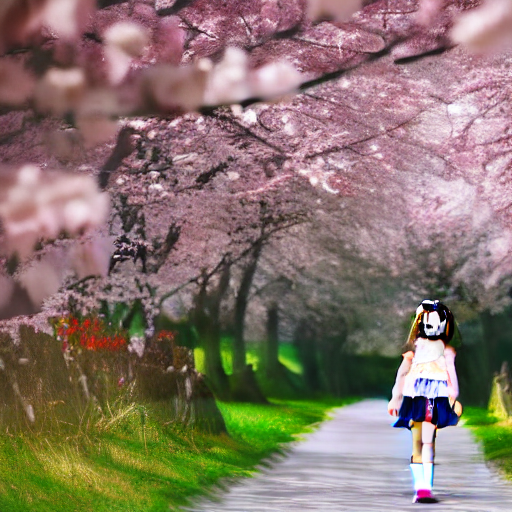

In [ ]:
# Test the pipeline with a simple prompt

prompt = "an anime girl walking under cherry blossoms, cinematic, high quality"
image = pipe(prompt, num_inference_steps=10).images[0]
image

In [ ]:
# Load AnimateDiff pipeline

import torch
from diffusers import AnimateDiffPipeline, MotionAdapter, DDIMScheduler

device = "mps" if torch.backends.mps.is_available() else "cpu"
dtype = torch.float32  # safest on Mac

print("device:", device)
print("dtype:", dtype)

adapter = MotionAdapter.from_pretrained(
    "guoyww/animatediff-motion-adapter-v1-5-2", torch_dtype=dtype
)

anim_pipe = AnimateDiffPipeline.from_pretrained(
    "models/base_sd",
    motion_adapter=adapter,
    torch_dtype=dtype,
    safety_checker=None,
    requires_safety_checker=False,
)

anim_pipe.scheduler = DDIMScheduler.from_pretrained(
    "models/base_sd",
    subfolder="scheduler",
    clip_sample=False,
    timestep_spacing="linspace",
    beta_schedule="linear",
    steps_offset=1,
)

anim_pipe = anim_pipe.to(device)
anim_pipe.enable_attention_slicing()

print("AnimateDiff pipeline loaded")

device: mps
dtype: torch.float32


/Users/arushisingh/miniconda3/lib/python3.10/site-packages/huggingface_hub/file_download.py:1142: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
The config attributes {'motion_activation_fn': 'geglu', 'motion_attention_bias': False, 'motion_cross_attention_dim': None} were passed to MotionAdapter, but are not expected and will be ignored. Please verify your config.json configuration file.
Keyword arguments {'safety_checker': None, 'requires_safety_checker': False} are not expected by AnimateDiffPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

The config attributes {'center_input_sample': False, 'flip_sin_to_cos': True, 'freq_shift': 0, 'attention_head_dim': 8} were passed to UNetMotionModel, but are not expected and will be ignored. Please verify your config.json configuration file.


AnimateDiff pipeline loaded


In [ ]:
# Test with a very small clip

from diffusers.utils import export_to_gif
import os

os.makedirs("outputs", exist_ok=True)

prompt = (
    "anime girl walking under cherry blossoms, cinematic, high quality, soft lighting"
)

output = anim_pipe(
    prompt=prompt,
    negative_prompt="blurry, low quality, distorted, worst quality",
    num_frames=4,  # ↓ from 8 → 4
    num_inference_steps=4,  # ↓ from 8 → 4
    height=256,  # ↓ from 512 → 256
    width=256,  # ↓ from 512 → 256
    guidance_scale=6.0,  # slightly lower = lighter compute
    generator=torch.Generator(device=device).manual_seed(42),
)

gif_path = "outputs/test_anim_small.gif"
export_to_gif(output.frames[0], gif_path)

print("Saved to:", gif_path)

  0%|          | 0/4 [00:00<?, ?it/s]

Saved to: outputs/test_anim_small.gif


In [15]:
import gc
import torch

gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

print("Cleared memory")

Cleared memory


In [ ]:
# from diffusers.utils import export_to_gif
# import os

# os.makedirs("outputs", exist_ok=True)

# prompt = "anime girl walking under cherry blossoms, cinematic, high quality, soft lighting, detailed anime background"

# output = anim_pipe(
#     prompt=prompt,
#     negative_prompt="blurry, noisy, distorted, low quality, worst quality, deformed",
#     num_frames=4,
#     num_inference_steps=8,
#     height=256,
#     width=256,
#     guidance_scale=7.5,
#     generator=torch.Generator(device=device).manual_seed(42),
# )

# gif_path = "outputs/test_anim_better.gif"
# export_to_gif(output.frames[0], gif_path)

# print("Saved to:", gif_path)

  0%|          | 0/8 [00:00<?, ?it/s]

Saved to: outputs/test_anim_better.gif


In [ ]:
import gc
import torch

gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()

from diffusers.utils import export_to_gif
import os

prompt = "anime girl walking under cherry blossom trees, soft lighting, cinematic, anime style, detailed"

output = anim_pipe(
    prompt=prompt,
    negative_prompt="blurry, noisy, distorted, worst quality, glitch, artifacts",
    num_frames=4,
    num_inference_steps=15,  # BIG change (8 → 15)
    height=256,
    width=256,
    guidance_scale=6.5,  # slightly lower = more stable
    generator=torch.Generator(device=device).manual_seed(42),
)

gif_path = "outputs/test_anim_stable.gif"
export_to_gif(output.frames[0], gif_path)

print("Saved to:", gif_path)

  0%|          | 0/15 [00:00<?, ?it/s]

Saved to: outputs/test_anim_stable.gif


## 3- Test with JacobLin Data

In [ ]:
# Test if files exist

from pathlib import Path

raw_dir = Path("data/raw")

print("Exists:", raw_dir.exists())
print("Files:")
for p in sorted(raw_dir.rglob("*")):
    if p.is_file():
        print(p)

Exists: True
Files:
data/raw/.gitkeep
